In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_csv("ecommercechurn.csv")

In [4]:
df.head(10)

,age,country,signup_date,last_purchase_date,subscription_status,order_date,unit_price,quantity,revenue,purchase_frequency,category,gender
0,39,Canada,1/7/2021,2/21/2023,active,8/20/2024,78.21,5,391.0,37,Sports,Female
1,61,USA,10/19/2020,12/8/2021,active,7/17/2025,64.02,8,512.2,35,Home,Female
2,26,Pakistan,6/10/2023,9/4/2023,cancelled,3/12/2025,604.14,2,1208.3,44,Clothing,Female
3,54,India,7/30/2023,2/20/2024,paused,9/19/2024,84.66,4,338.6,1,Beauty,Male
4,50,India,12/9/2020,9/14/2024,active,8/8/2024,62.66,7,438.6,35,Electronics,Male
5,46,Pakistan,5/16/2023,8/13/2025,active,10/14/2024,221.61,8,1772.9,16,Clothing,Male
6,29,Germany,4/10/2023,7/15/2025,active,3/5/2024,175.74,4,703.0,7,Electronics,Female
7,24,UK,7/11/2022,12/31/2024,active,3/21/2025,9.56,5,47.8,34,Clothing,Female
8,53,Pakistan,4/25/2021,12/26/2024,paused,12/14/2023,1525.80,1,1525.8,32,Beauty,Female
9,38,Germany,12/9/2021,11/29/2024,active,12/24/2021,337.24,4,1349.0,6,Electronics,Male


In [5]:
df.info() # View non-nulls and types for each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1000 non-null   int64  
 1   country              1000 non-null   object 
 2   signup_date          1000 non-null   object 
 3   last_purchase_date   1000 non-null   object 
 4   subscription_status  1000 non-null   object 
 5   order_date           1000 non-null   object 
 6   unit_price           1000 non-null   float64
 7   quantity             1000 non-null   int64  
 8   revenue              1000 non-null   float64
 9   purchase_frequency   1000 non-null   int64  
 10  category             1000 non-null   object 
 11  gender               1000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 93.9+ KB


In [6]:
df.duplicated().sum() # Checking for duplicates

0

In [7]:
# How many customers have are subscribed?
df.value_counts(['subscription_status'], normalize=True)

subscription_status
active                 0.609
cancelled              0.248
paused                 0.143
Name: proportion, dtype: float64

In [3]:
# Create annual recurring revenue column
df['arr'] = np.where(df['subscription_status'] == 'active', df['revenue'], 0)

In [12]:
df.head()

,age,country,signup_date,last_purchase_date,subscription_status,order_date,unit_price,quantity,revenue,purchase_frequency,category,gender,arr
0,39,Canada,1/7/2021,2/21/2023,active,8/20/2024,78.21,5,391.0,37,Sports,Female,391.0
1,61,USA,10/19/2020,12/8/2021,active,7/17/2025,64.02,8,512.2,35,Home,Female,512.2
2,26,Pakistan,6/10/2023,9/4/2023,cancelled,3/12/2025,604.14,2,1208.3,44,Clothing,Female,0.0
3,54,India,7/30/2023,2/20/2024,paused,9/19/2024,84.66,4,338.6,1,Beauty,Male,0.0
4,50,India,12/9/2020,9/14/2024,active,8/8/2024,62.66,7,438.6,35,Electronics,Male,438.6


In [13]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

In [14]:
numerical_cols

['age', 'unit_price', 'quantity', 'revenue', 'purchase_frequency', 'arr']

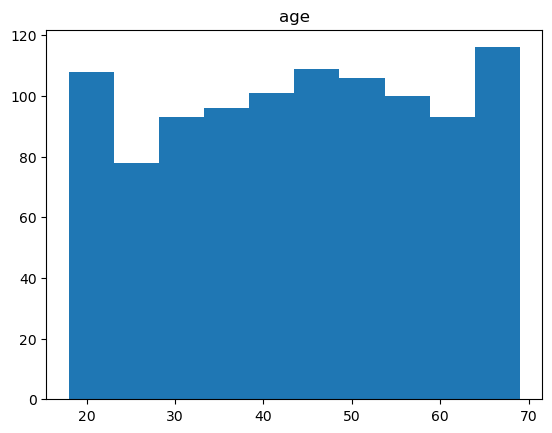

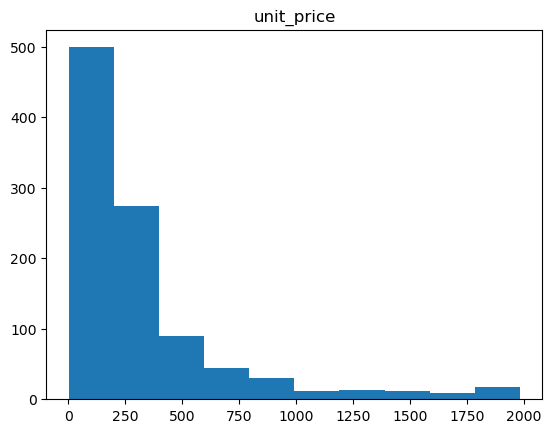

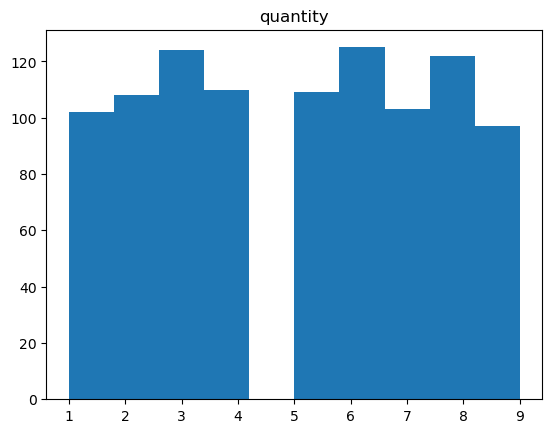

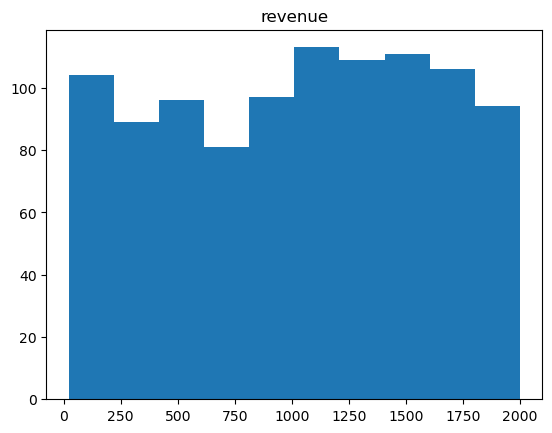

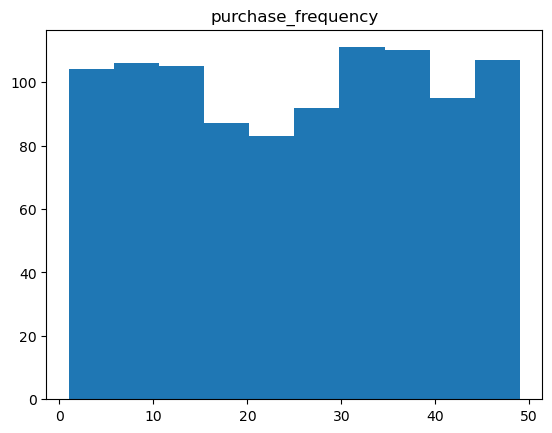

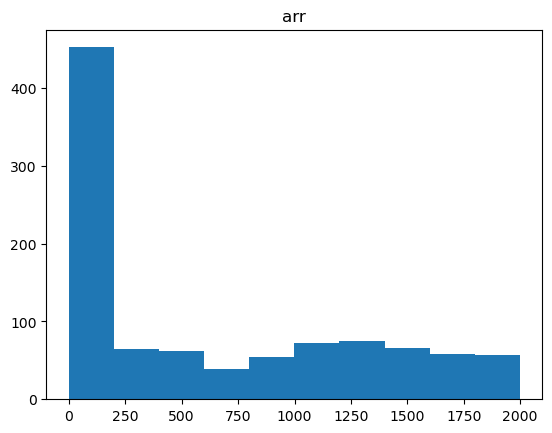

In [32]:
# View distributions for numerical columns
for i in numerical_cols:
    plt.hist(x=df[i])
    plt.title(i)
    plt.show()
    plt.close()

In [34]:
df.to_csv('ecommercefortableau.csv') # Export cleaned dataframe for Tableau

In [4]:
df_encoded = pd.get_dummies(df, columns=['country', 'category', 'gender'])

In [15]:
df_encoded.head()

,age,signup_date,last_purchase_date,subscription_status,order_date,unit_price,quantity,revenue,purchase_frequency,arr,...,country_UK,country_USA,category_Beauty,category_Clothing,category_Electronics,category_Home,category_Sports,gender_Female,gender_Male,gender_Other
0,39,1/7/2021,2/21/2023,active,8/20/2024,78.21,5,391.0,37,391.0,...,False,False,False,False,False,False,True,True,False,False
1,61,10/19/2020,12/8/2021,active,7/17/2025,64.02,8,512.2,35,512.2,...,False,True,False,False,False,True,False,True,False,False
2,26,6/10/2023,9/4/2023,cancelled,3/12/2025,604.14,2,1208.3,44,0.0,...,False,False,False,True,False,False,False,True,False,False
3,54,7/30/2023,2/20/2024,paused,9/19/2024,84.66,4,338.6,1,0.0,...,False,False,True,False,False,False,False,False,True,False
4,50,12/9/2020,9/14/2024,active,8/8/2024,62.66,7,438.6,35,438.6,...,False,False,False,False,True,False,False,False,True,False


In [5]:
X = df_encoded.drop(columns=['subscription_status', 'signup_date', 'last_purchase_date', 'order_date'])
y = df_encoded['subscription_status']

In [6]:
train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42, test_size=0.2)

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [8]:
rf = RandomForestClassifier(random_state=42)

In [9]:
rfgrid = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

In [10]:
rfgrid.fit(train_X, train_y)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.8s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   1.9s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=10, n_estimators=100; t

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [12]:
pred_y = rfgrid.predict(test_X)

In [14]:
f1 = f1_score(pred_y, test_y, average='weighted')
acc = accuracy_score(pred_y, test_y)

In [15]:
print('F1 Score:', f1)
print('Accuracy:', acc)

F1 Score: 0.8954689265536723
Accuracy: 0.89
